# XGBoost — Strategy B: Random Undersampling

XGBoost is trained using random undersampling to balance the training data by reducing the majority class. This approach provides a direct comparison with SMOTE oversampling by using fewer non-diabetes samples instead of generating synthetic diabetes samples. Hyperparameter tuning is performed with stratified cross-validation, and the final model is evaluated on the original imbalanced test set.

In [7]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score, roc_auc_score, classification_report, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
import matplotlib.pyplot as plt
import numpy as np
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

In [8]:
X_train_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_train_final.parquet")
X_test_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_test_final.parquet")

y_train = pd.read_parquet("../DATASETS/PREPROCESSED/y_train.parquet")["diabetes"]
y_test = pd.read_parquet("../DATASETS/PREPROCESSED/y_test.parquet")["diabetes"]

In [9]:

pipeline = Pipeline([
    ("undersampling", RandomUnderSampler(random_state=42)),
    ("model", XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42, n_jobs=-1))
])

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.3, 0.5],
}


random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_final, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV ROC AUC:", random_search.best_score_)

Fitting 10 folds for each of 40 candidates, totalling 400 fits


Best parameters: {'model__subsample': 0.7, 'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__gamma': 0, 'model__colsample_bytree': 0.8}
Best CV ROC AUC: 0.8309948731694927


## Final Test Set Evaluation

After hyperparameter tuning, the best model is evaluated on the held-out test set. The test set is not resampled and therefore preserves the original class distribution. Performance is assessed using accuracy, precision, recall, F1-score, ROC AUC, and the confusion matrix.

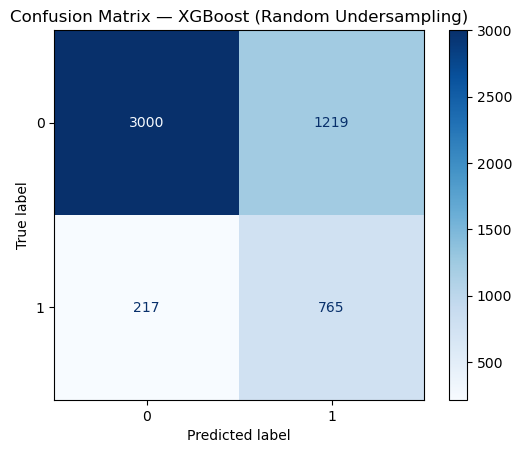

Confusion Matrix:
[[3000 1219]
 [ 217  765]]
Accuracy: 0.7239
ROC AUC: 0.8251

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.71      0.81      4219
         1.0       0.39      0.78      0.52       982

    accuracy                           0.72      5201
   macro avg       0.66      0.75      0.66      5201
weighted avg       0.83      0.72      0.75      5201



In [10]:
best_model = random_search.best_estimator_

predictions = best_model.predict(X_test_final)

pred_probabilities = best_model.predict_proba(X_test_final)[:, 1]

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — XGBoost (Random Undersampling)")
plt.show()

print("Confusion Matrix:")
print(cm)

accuracy = accuracy_score(y_test, predictions)
roc_auc = roc_auc_score(y_test, pred_probabilities)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

## Exporting Model Results

The final evaluation metrics are exported to a CSV file so they can be combined later in a separate model comparison notebook. This avoids retraining models when creating summary tables and visualizations.

In [11]:
metrics = {

    "Strategy": "Undersampling",

    "Model": "XGBoost",

    "Accuracy": accuracy_score(y_test, predictions),

    "Precision": precision_score(y_test, predictions),

    "Recall": recall_score(y_test, predictions),

    "F1-score": f1_score(y_test, predictions),

    "ROC AUC": roc_auc_score(y_test, pred_probabilities)

}

metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv("../RESULTS/PERFORMANCE/xgboost_undersampling_metrics.csv", index=False)